In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:

def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=100, fs=1000):
    tt = np.arange(nn)/fs
    
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    
    return tt, xx

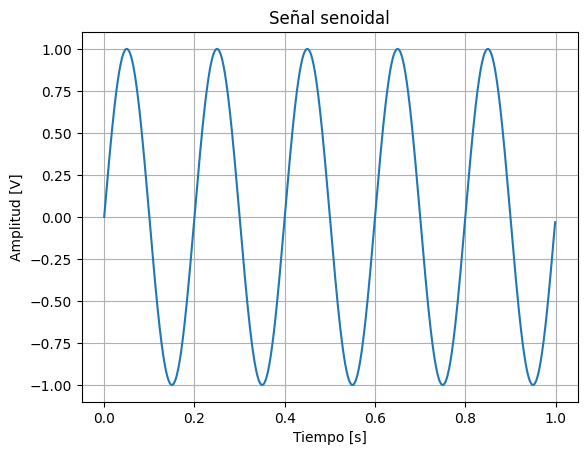

In [3]:

N = 1000
fs = 1000

tt, xx = mi_funcion_sen(vmax=1, dc=0, ff=5, ph=0, nn=N, fs=fs)

plt.plot(tt, xx)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud [V]")
plt.title("Señal senoidal")
plt.grid(True)
plt.show()

---

# Solucion estandar para multiples señales

In [4]:
class GeneradorSenales:

    @staticmethod
    def _resolver_parametros(ff, n, fs):
        """
        Resuelve fs y n en caso de no ser provistos
        (se trata de igualar fs y n, en caso de no haber valores de ambos -< se lleva a nyquist)
        """

        if fs is None and n is None:
            fs = ff * 2
            n = int(fs)

        elif fs is None:
            fs = n

        elif n is None:
            n = int(fs)

        return int(n), float(fs)

    @staticmethod
    def _generar_tiempo(n, fs):
        t = np.arange(n) / fs
        return t.reshape(-1, 1)

    @staticmethod
    def generar_seno(vmax=1, dc=0, ff=1, ph=0, n=None, fs=None):

        n, fs = GeneradorSenales._resolver_parametros(ff, n, fs)
        tt = GeneradorSenales._generar_tiempo(n, fs)

        xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)

        return tt, xx

    @staticmethod
    def generar_cuadrada(vmax=1, dc=0, ff=1, ph=0, n=None, fs=None):

        n, fs = GeneradorSenales._resolver_parametros(ff, n, fs)
        tt = GeneradorSenales._generar_tiempo(n, fs)

        xx = dc + vmax * np.sign(np.sin(2 * np.pi * ff * tt + ph))

        return tt, xx

    @staticmethod
    def generar_sawtooth(vmax=1, dc=0, ff=1, ph=0, n=None, fs=None):

        n, fs = GeneradorSenales._resolver_parametros(ff, n, fs)
        tt = GeneradorSenales._generar_tiempo(n, fs)

        # Fase expresada en ciclos
        fase_ciclos = ff * tt + ph / (2 * np.pi)

        rampa_01 = fase_ciclos - np.floor(fase_ciclos)

        # Escalar a -1 1
        xx = dc + vmax * (2 * rampa_01 - 1)

        return tt, xx

In [5]:
# @title Setup
gen = GeneradorSenales()


ff = 2
fs = 100
n = 200

plt.rcParams.update({
    "figure.figsize": (10,4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11
})

def plot_signal(t, x, title):
    fig, ax = plt.subplots()

    ax.plot(t, x, linewidth=2)

    ax.set_title(title)
    ax.set_xlabel("Tiempo [s]")
    ax.set_ylabel("Amplitud")

    ax.set_xlim(t.min(), t.max())

    ax.grid(True)

    plt.tight_layout()
    plt.show()


### Seno

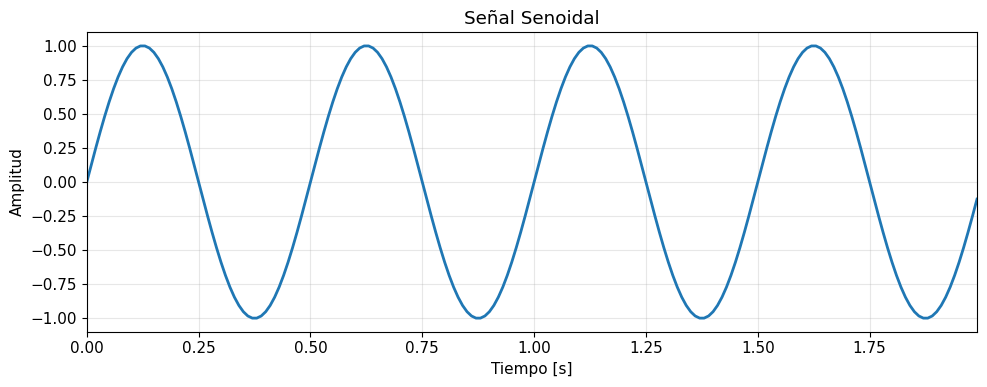

In [6]:
t, x = GeneradorSenales.generar_seno(ff=ff, fs=fs, n=n)
plot_signal(t, x, "Señal Senoidal")

### Cuadrada

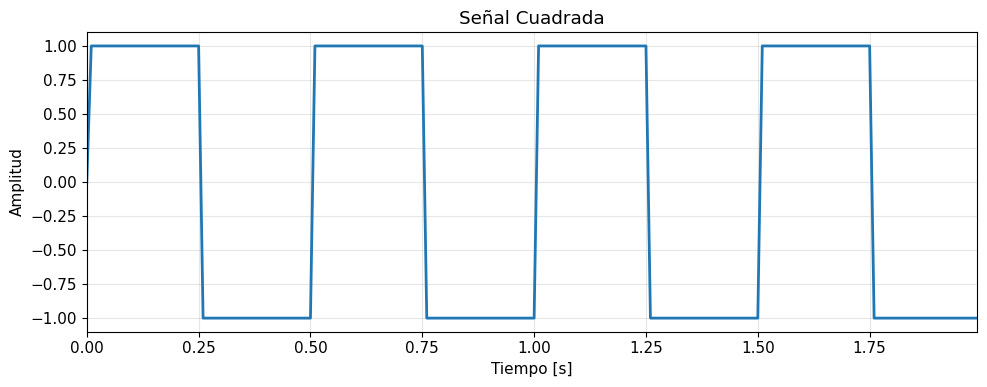

In [7]:
t, x = GeneradorSenales.generar_cuadrada(ff=ff, fs=fs, n=n)
plot_signal(t, x, "Señal Cuadrada")


### Sawthoot

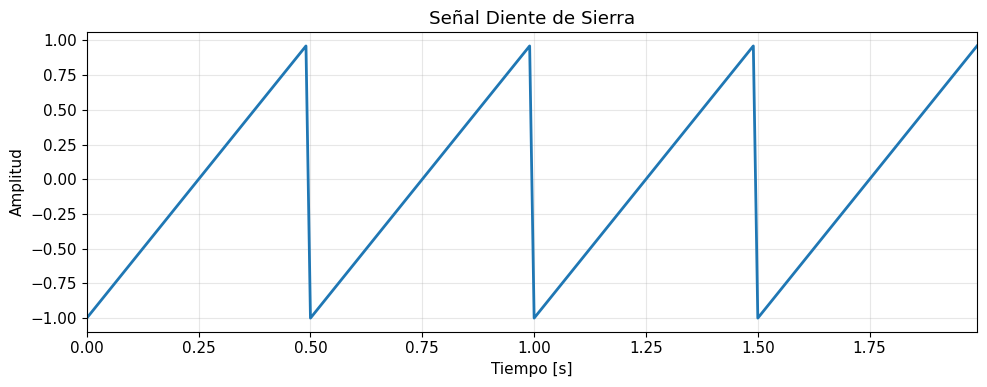

In [8]:
t, x = GeneradorSenales.generar_sawtooth(ff=ff, fs=fs, n=n)
plot_signal(t, x, "Señal Diente de Sierra")